In [1]:
import sys
sys.path.append("./helper")

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import pickle

## Discrepancy between true loss and optimizer loss

In [2]:
wd = "seir_16_age_results/varying_parms/"

with open(wd + "seir_16_age_nm_nm_query_incs.pkl", "rb") as f:
    nm_nm_query_incs = np.array(pickle.load(f))
with open(wd + "seir_16_age_nm_nm_best_loss.pkl", "rb") as f:
    nm_nm_best_loss = np.array(pickle.load(f))
with open(wd + "seir_16_age_nm_nm_true_loss.pkl", "rb") as f:
    nm_nm_true_loss = np.array(pickle.load(f))

with open(wd + "seir_16_age_rf_nm_query_incs.pkl", "rb") as f:
    rf_nm_query_incs = np.array(pickle.load(f))
with open(wd + "seir_16_age_rf_nm_best_loss.pkl", "rb") as f:
    rf_nm_best_loss = np.array(pickle.load(f))
with open(wd + "seir_16_age_rf_nm_true_loss.pkl", "rb") as f:
    rf_nm_true_loss = np.array(pickle.load(f))

In [3]:
# 1000 queries
nm_nm_1000 = nm_nm_best_loss[:, 0]
rf_nm_1000 = rf_nm_best_loss[:, 0]
# 2000 queries
nm_nm_2000 = nm_nm_best_loss[:, 1]
rf_nm_2000 = rf_nm_best_loss[:, 1]
# 3000 queries
nm_nm_3000 = nm_nm_best_loss[:, 2]
rf_nm_3000 = rf_nm_best_loss[:, 2]
# 4000 queries
nm_nm_4000 = nm_nm_best_loss[:, 3]
rf_nm_4000 = rf_nm_best_loss[:, 3]
# 5000 queries
nm_nm_5000 = nm_nm_best_loss[:, 4]
rf_nm_5000 = rf_nm_best_loss[:, 4]
# 6000 queries
nm_nm_6000 = nm_nm_best_loss[:, 5]
rf_nm_6000 = rf_nm_best_loss[:, 5]

# group arrays for plotting
best_loss_all = [[nm_nm_1000, nm_nm_2000, nm_nm_3000, nm_nm_4000, nm_nm_5000, nm_nm_6000],
                 [rf_nm_1000, rf_nm_2000, rf_nm_3000, rf_nm_4000, rf_nm_5000, rf_nm_6000]]
true_loss_all = [[nm_nm_true_loss, nm_nm_true_loss, nm_nm_true_loss, nm_nm_true_loss, nm_nm_true_loss, nm_nm_true_loss],
                 [rf_nm_true_loss, rf_nm_true_loss, rf_nm_true_loss, rf_nm_true_loss, rf_nm_true_loss, rf_nm_true_loss]]

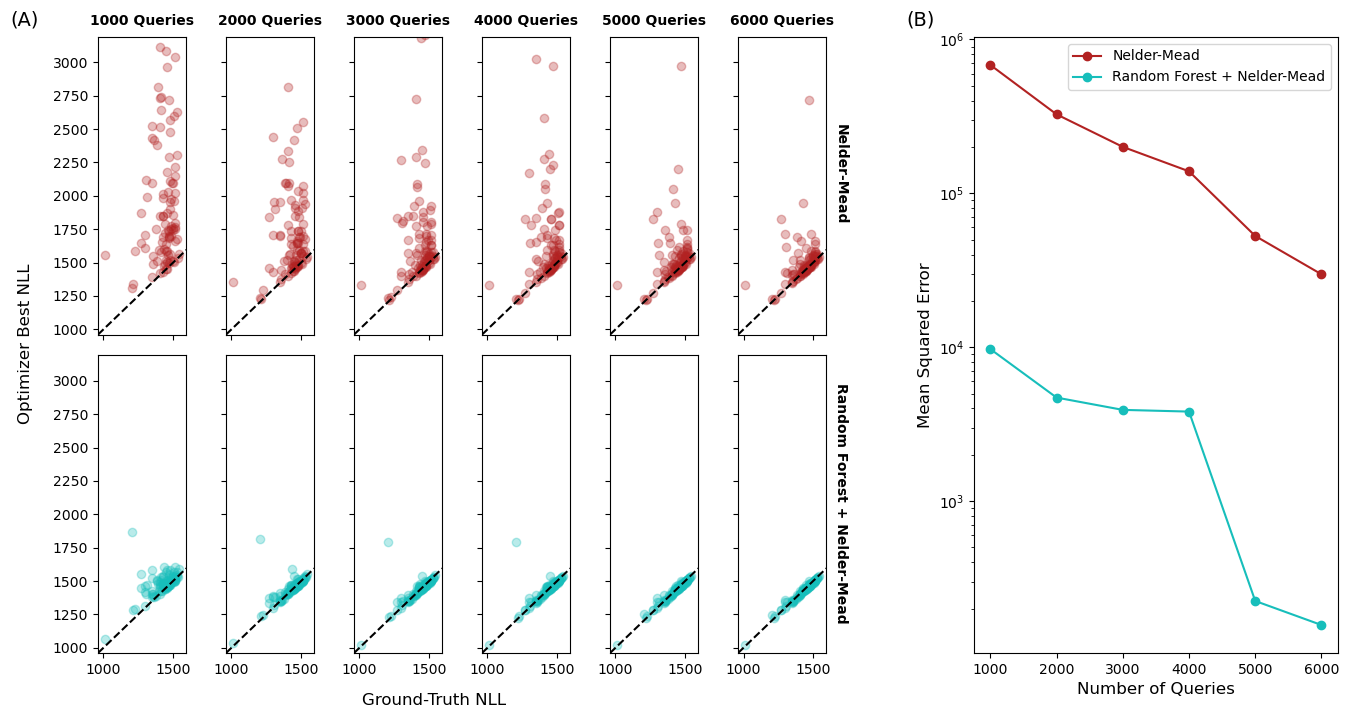

In [4]:
# combined figure
fig = plt.figure(figsize=(16, 8))
gs = fig.add_gridspec(1, 2, width_ratios=[2, 1], wspace=0.27)

# (A) LEFT PANEL: Individual runs
ax_left = gs[0].subgridspec(2, 6, wspace=0.45, hspace=0.07)
axes_left = np.empty((2, 6), dtype=object)

for row in range(2):
    for col in range(6):
        axes_left[row, col] = fig.add_subplot(ax_left[row, col])

        cur_best_loss = best_loss_all[row][col]
        cur_true_loss = true_loss_all[row][col]
        loss_min = np.min(cur_true_loss) - 50
        loss_max = np.max(cur_true_loss) + 50

        pt_col = "#b22222" if row == 0 else "#17BEBB"
        axes_left[row, col].scatter(cur_true_loss, cur_best_loss, alpha=0.3, color=pt_col)
        axes_left[row, col].plot([loss_min, loss_max], [loss_min, loss_max], "--", color="black")
        axes_left[row, col].set_xlim(loss_min, loss_max)
        axes_left[row, col].set_ylim(loss_min, loss_max * 2)

        # hide tick labels
        if row == 0:
            axes_left[row, col].tick_params(axis='x', which='both', labelbottom=False)
        if col != 0:
            axes_left[row, col].tick_params(axis='y', which='both', labelleft=False)

# Shared labels
fig.text(0.29, 0.045, "Ground-Truth NLL", fontsize=12)
fig.text(0.075, 0.40, "Optimizer Best NLL", fontsize=12, rotation=90)

# Add column titles
fig.text(x=0.120, y=0.895, s="1000 Queries", fontsize=10, fontweight="bold")
fig.text(x=0.200, y=0.895, s="2000 Queries", fontsize=10, fontweight="bold")
fig.text(x=0.280, y=0.895, s="3000 Queries", fontsize=10, fontweight="bold")
fig.text(x=0.360, y=0.895, s="4000 Queries", fontsize=10, fontweight="bold")
fig.text(x=0.440, y=0.895, s="5000 Queries", fontsize=10, fontweight="bold")
fig.text(x=0.520, y=0.895, s="6000 Queries", fontsize=10, fontweight="bold")

# Row titles
fig.text(0.585, 0.65, "Nelder-Mead", fontsize=10, fontweight="bold", rotation=-90)
fig.text(0.585, 0.15, "Random Forest + Nelder-Mead", fontsize=10, fontweight="bold", rotation=-90)

# (B) RIGHT PANEL: MSE line plot
ax_right = fig.add_subplot(gs[1])

query_incs = [1000, 2000, 3000, 4000, 5000, 6000]
nm_nm_mse = []
for i in range(6):
    best_loss = best_loss_all[0][i]
    mse = np.mean((true_loss_all[0][i] - best_loss) ** 2)
    nm_nm_mse.append(mse)

rf_nm_mse = []
for i in range(6):
    best_loss = best_loss_all[1][i]
    mse = np.mean((true_loss_all[1][i] - best_loss) ** 2)
    rf_nm_mse.append(mse)

ax_right.plot(query_incs, nm_nm_mse, color="#b22222", marker="o", label="Nelder-Mead")
ax_right.plot(query_incs, rf_nm_mse, color="#17BEBB", marker="o", label="Random Forest + Nelder-Mead")
ax_right.set_yscale("log")
ax_right.set_xlabel("Number of Queries", fontsize=12)
ax_right.set_ylabel("Mean Squared Error", fontsize=12)
ax_right.legend()

# Add (A) and (B) labels
fig.text(0.070, 0.895, "(A)", fontsize=14)
fig.text(0.630, 0.895, "(B)", fontsize=14)

plt.savefig(
    "figures/Fig4.tif",
    dpi=300,
    bbox_inches="tight"
)